# 215 — HG downsampling internal test (L1)

Tests whether the high-gamma (70–150 Hz band-mean) time-series features
can be downsampled from 300 time bins to a smaller N without losing
clustering quality. Parallel question to what 212 answered for raw ERSP
(band-aware downsampling 129×300 → 15×30 = 450 features).

**This is L1 — pure validation. No new `index.json` entry, no
`fit_and_save`, no MOBA wiring. Just answers: *is downsampling worth
productionizing?* If the answer is yes, follow up with a full L2
pipeline (a new `hgds` feature_set parallel to `rawds`).**

## Pipeline

1. Load X_hg from an existing hg run's `X_train.npy` (full 300-d, already
   on the canonical sample set).
2. Downsample to N ∈ `N_TIME_OUT_SWEEP` via `skimage.transform.resize`
   (anti-aliased, same primitive 212 uses for rawds).
3. For each N, run KMeans at K = the reference run's `n_clusters`,
   compute:
    * Silhouette
    * ARI vs full-HG labels (how much does the clustering CHANGE?)
    * Per-cluster Jaccard from Monti consensus (`N_RUNS=30`, `subsample_frac=0.80`)
    * Mean anatomy purity (Desikan-Killiany aparc, reusing 211's cache)
4. Plot a 2×2 tradeoff curve and save:
    * `outputs/clustering/hg_downsampling_test/results.csv`
    * `outputs/clustering/hg_downsampling_test/tradeoff_curves.png`

**What a 'good' downsample looks like:** ARI vs full ≥ 0.85 (essentially
the same clustering), silhouette similar or higher, Jaccard similar or
higher, purity similar.

**Reads from existing paths only:**
* `<ref_run>/X_train.npy` and `<ref_run>/labels.csv`
* `outputs/250_recon/fsaverage/aparc_lookup.csv` (211's cache)

**Writes to a new sibling of `comparisons/`:** `outputs/clustering/hg_downsampling_test/`.

## 0 — Imports + paths

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.transform import resize
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

sys.path.insert(0, str(Path('..').resolve()))
from functions.lf_stability import compute_consensus_matrix, per_cluster_jaccard
from functions.lf_anatomy import cluster_anatomy_purity
from functions import lf_cluster_run as R

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
INDEX_PATH     = CLUSTERING_DIR / 'index.json'
APARC_CACHE    = CLUSTERING_DIR.parent / '250_recon' / 'fsaverage' / 'aparc_lookup.csv'
REPORT_DIR     = CLUSTERING_DIR / 'hg_downsampling_test'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

with open(INDEX_PATH) as f:
    INDEX = json.load(f)
print(f'INDEX: {len(INDEX["runs"])} runs')
print(f'REPORT_DIR: {REPORT_DIR}')

INDEX: 45 runs
REPORT_DIR: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hg_downsampling_test


## 1 — Config

In [2]:
# Reference run: which hg run is the 'full' baseline. Picks the latest by
# default. Override if you want to compare against a specific one.
REF_METHOD       = 'kmeans'     # kmeans for stable per-K silhouette baseline
REF_FEATURE_SET  = 'hg'
REF_RUN_ID       = None         # None = pick latest from INDEX

# Downsampling sweep. Original HG = 300 time bins (one per 10 ms in your
# canonical window). Pick the boundary you care about.
N_TIME_OUT_SWEEP = [15, 30, 50, 100, 200, 300]   # 300 = full (sanity check)

# KMeans
RANDOM_STATE = 42
N_INIT       = 10

# Consensus matrix (Monti et al. 2003).
# N_RUNS=30 is a faster default than 213's 50 for this exploratory test;
# Jaccard estimates stabilize by ~30 for typical n×K.
N_RUNS         = 100
SUBSAMPLE_FRAC = 0.80

print(f'sweep N_TIME_OUT: {N_TIME_OUT_SWEEP}')
print(f'consensus N_RUNS={N_RUNS}  subsample_frac={SUBSAMPLE_FRAC}')
print(f'KMeans random_state={RANDOM_STATE}  n_init={N_INIT}')

sweep N_TIME_OUT: [15, 30, 50, 100, 200, 300]
consensus N_RUNS=100  subsample_frac=0.8
KMeans random_state=42  n_init=10


## 2 — Load reference HG run + aparc cache

In [3]:
def _latest_run(method, feature_set):
    cands = [r for r in INDEX['runs']
             if r['method'] == method and r['feature_set'] == feature_set]
    if not cands: return None
    return sorted(cands, key=lambda r: r['run_id'])[-1]

if REF_RUN_ID:
    ref_run = next((r for r in INDEX['runs']
                   if r['method'] == REF_METHOD
                   and r['feature_set'] == REF_FEATURE_SET
                   and r['run_id'] == REF_RUN_ID), None)
else:
    ref_run = _latest_run(REF_METHOD, REF_FEATURE_SET)

assert ref_run is not None, f'No {REF_METHOD}/{REF_FEATURE_SET} run found.'
ref_run_dir = CLUSTERING_DIR / ref_run['path']
print(f'Reference run: {ref_run["path"]}  K={ref_run["n_clusters"]}  sil={ref_run["silhouette"]:.3f}')

X_full = np.load(ref_run_dir / 'X_train.npy')
df_labels_full = pd.read_csv(ref_run_dir / 'labels.csv')
cluster_col = f'cluster_{ref_run["method"]}_{ref_run["feature_set"]}'
if cluster_col not in df_labels_full.columns:
    cands = [c for c in df_labels_full.columns if c.startswith('cluster_') and not c.endswith('_ranked')]
    cluster_col = cands[0] if cands else cluster_col
labels_full = df_labels_full[cluster_col].to_numpy()

K_REF = int(ref_run['n_clusters'])
N_FULL = int(X_full.shape[1])
print(f'X_full.shape={X_full.shape}  K_REF={K_REF}')
print(f'labels_full: {len(labels_full)} samples, {len(np.unique(labels_full))} unique clusters')

assert APARC_CACHE.exists(), f'aparc cache missing: {APARC_CACHE}'
df_aparc = pd.read_csv(APARC_CACHE)
print(f'aparc cache: {len(df_aparc)} electrodes, {df_aparc["aparc_label"].nunique()} unique aparc labels')

Reference run: kmeans/hg/runs/20260530_151837  K=5  sil=0.186
X_full.shape=(1538, 300)  K_REF=5
labels_full: 1538 samples, 5 unique clusters
aparc cache: 3953 electrodes, 34 unique aparc labels


## 3 — Helpers

In [4]:
def downsample_hg(X, n_out):
    """Anti-aliased resize of each row from (n_full,) to (n_out,).
    Same skimage primitive 212 uses for its time-axis resample."""
    n_samples, n_full = X.shape
    if n_out == n_full:
        return X.copy().astype(np.float32)
    return resize(X, (n_samples, n_out), anti_aliasing=True, mode='reflect').astype(np.float32)


def cluster_and_score(X, k, *,
                       ref_labels, df_labels, df_aparc, cluster_col_name,
                       n_runs, subsample_frac, random_state, n_init,
                       verbose=True):
    """
    Fit KMeans at K=k on X, then compute:
      silhouette · ARI vs ref_labels · per-cluster Jaccard (Monti) · mean anatomy purity
    Returns dict.
    """
    km = KMeans(n_clusters=int(k), random_state=int(random_state), n_init=int(n_init)).fit(X)
    labels = km.labels_

    sil = float(silhouette_score(X, labels)) if len(np.unique(labels)) > 1 else float('nan')
    ari = float(adjusted_rand_score(ref_labels, labels))

    if verbose:
        print(f'    consensus matrix at K={k}, N_RUNS={n_runs}, subsample={subsample_frac:.2f}...')
    C = compute_consensus_matrix(
        X, int(k),
        n_runs=int(n_runs),
        subsample_frac=float(subsample_frac),
        random_state=int(random_state),
        verbose=False,
    )
    jacc = per_cluster_jaccard(labels, C)
    finite_jacc = [v for v in jacc.values() if not np.isnan(v)]
    mean_jacc = float(np.mean(finite_jacc)) if finite_jacc else float('nan')

    df_l = df_labels.copy()
    df_l[cluster_col_name] = labels
    anat = cluster_anatomy_purity(df_l, df_aparc, cluster_col=cluster_col_name, n_perm=0)
    finite_purity = [v['purity'] for v in anat.values()
                     if v.get('purity') is not None and not np.isnan(v['purity'])]
    mean_purity = float(np.mean(finite_purity)) if finite_purity else float('nan')

    return {
        'silhouette':  sil,
        'ari_vs_full': ari,
        'mean_jaccard': mean_jacc,
        'mean_purity': mean_purity,
        'labels':      labels,
    }

## 4 — Sweep N_TIME_OUT

In [5]:
results = []
for n_out in N_TIME_OUT_SWEEP:
    print(f'\n--- N_TIME_OUT = {n_out} ---')
    X_ds = downsample_hg(X_full, n_out)
    print(f'  X shape: {X_full.shape} -> {X_ds.shape}')
    metrics = cluster_and_score(
        X_ds, K_REF,
        ref_labels=labels_full,
        df_labels=df_labels_full,
        df_aparc=df_aparc,
        cluster_col_name=cluster_col,
        n_runs=N_RUNS, subsample_frac=SUBSAMPLE_FRAC,
        random_state=RANDOM_STATE, n_init=N_INIT,
    )
    print(f'  silhouette={metrics["silhouette"]:.3f}  '
          f'ARI_vs_full={metrics["ari_vs_full"]:.3f}  '
          f'mean_jaccard={metrics["mean_jaccard"]:.3f}  '
          f'mean_purity={metrics["mean_purity"]:.3f}')
    results.append({
        'n_time_out':        int(n_out),
        'compression_ratio': float(n_out) / float(N_FULL),
        'silhouette':        metrics['silhouette'],
        'ari_vs_full':       metrics['ari_vs_full'],
        'mean_jaccard':      metrics['mean_jaccard'],
        'mean_purity':       metrics['mean_purity'],
    })

df_results = pd.DataFrame(results)
print('\n=== Summary ===')
print(df_results.to_string(index=False, float_format=lambda v: f'{v:.3f}'))


--- N_TIME_OUT = 15 ---
  X shape: (1538, 300) -> (1538, 15)
    consensus matrix at K=5, N_RUNS=100, subsample=0.80...
  silhouette=0.246  ARI_vs_full=0.953  mean_jaccard=0.801  mean_purity=0.282

--- N_TIME_OUT = 30 ---
  X shape: (1538, 300) -> (1538, 30)
    consensus matrix at K=5, N_RUNS=100, subsample=0.80...
  silhouette=0.228  ARI_vs_full=0.640  mean_jaccard=0.871  mean_purity=0.320

--- N_TIME_OUT = 50 ---
  X shape: (1538, 300) -> (1538, 50)
    consensus matrix at K=5, N_RUNS=100, subsample=0.80...
  silhouette=0.212  ARI_vs_full=0.972  mean_jaccard=0.828  mean_purity=0.281

--- N_TIME_OUT = 100 ---
  X shape: (1538, 300) -> (1538, 100)
    consensus matrix at K=5, N_RUNS=100, subsample=0.80...
  silhouette=0.199  ARI_vs_full=0.631  mean_jaccard=0.862  mean_purity=0.319

--- N_TIME_OUT = 200 ---
  X shape: (1538, 300) -> (1538, 200)
    consensus matrix at K=5, N_RUNS=100, subsample=0.80...
  silhouette=0.188  ARI_vs_full=0.873  mean_jaccard=0.882  mean_purity=0.316

--- N

## 5 — Tradeoff plot + save report

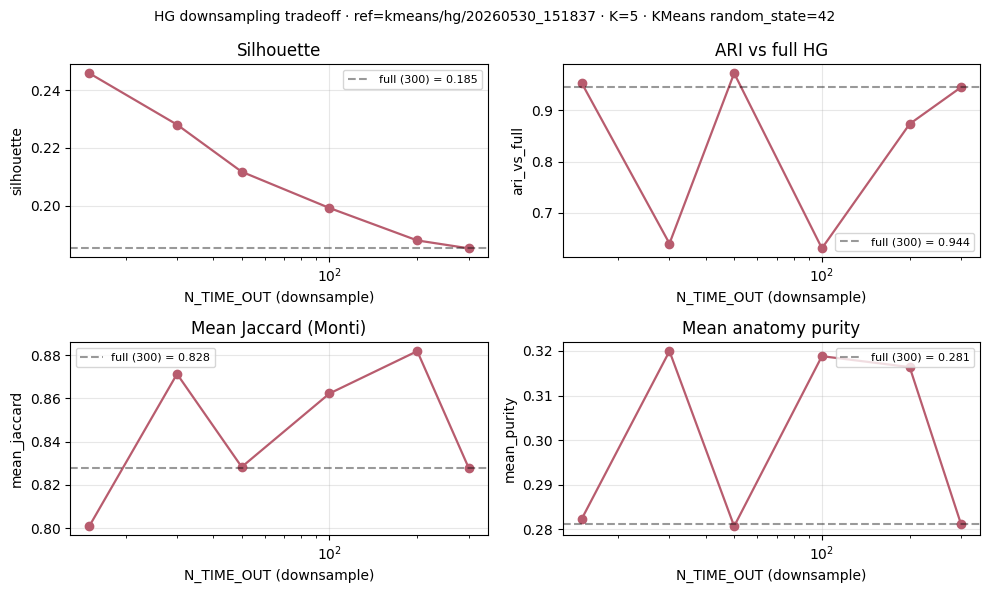


Wrote:
  \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hg_downsampling_test\results.csv
  \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hg_downsampling_test\tradeoff_curves.png
  \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hg_downsampling_test\config.json


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
panels = [
    ('silhouette',  'Silhouette',           '+'),
    ('ari_vs_full', 'ARI vs full HG',       '+'),
    ('mean_jaccard','Mean Jaccard (Monti)', '+'),
    ('mean_purity', 'Mean anatomy purity',  '+'),
]
for ax, (col, title, _) in zip(axes.ravel(), panels):
    ax.plot(df_results['n_time_out'], df_results[col], marker='o', lw=1.6, color='#b85c6e')
    # Mark full-resolution value as a horizontal reference
    if N_FULL in df_results['n_time_out'].values:
        full_v = df_results.loc[df_results['n_time_out'] == N_FULL, col].iloc[0]
        ax.axhline(full_v, ls='--', color='black', alpha=0.4, label=f'full ({N_FULL}) = {full_v:.3f}')
        ax.legend(loc='best', fontsize=8)
    ax.set_xlabel('N_TIME_OUT (downsample)')
    ax.set_ylabel(col)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.set_xscale('log')
fig.suptitle(
    f'HG downsampling tradeoff · ref={ref_run["method"]}/{ref_run["feature_set"]}/{ref_run["run_id"]} '
    f'· K={K_REF} · KMeans random_state={RANDOM_STATE}',
    fontsize=10,
)
fig.tight_layout()
fig.savefig(REPORT_DIR / 'tradeoff_curves.png', dpi=130, bbox_inches='tight')
plt.show()

df_results.to_csv(REPORT_DIR / 'results.csv', index=False)

config_dump = {
    'reference_run':    {
        'method':      ref_run['method'],
        'feature_set': ref_run['feature_set'],
        'run_id':      ref_run['run_id'],
        'n_clusters':  K_REF,
        'n_full':      N_FULL,
    },
    'n_time_out_sweep': N_TIME_OUT_SWEEP,
    'random_state':     RANDOM_STATE,
    'n_init':           N_INIT,
    'consensus':        {'n_runs': N_RUNS, 'subsample_frac': SUBSAMPLE_FRAC},
}
(REPORT_DIR / 'config.json').write_text(json.dumps(config_dump, indent=2))

print(f'\nWrote:')
print(f'  {REPORT_DIR / "results.csv"}')
print(f'  {REPORT_DIR / "tradeoff_curves.png"}')
print(f'  {REPORT_DIR / "config.json"}')

## 6 — How to read the result

Look at the tradeoff curves and the results table above.

| Metric | Interpretation |
|---|---|
| **Silhouette** | Internal cluster compactness. Lower-d feature spaces sometimes lift silhouette by reducing curse-of-dim. Should be similar or higher than full. |
| **ARI vs full** | How much does the clustering CHANGE? 1.0 = identical labels, 0 = random. >0.85 = essentially same clustering. |
| **Mean Jaccard** | Per-cluster stability under resampling (Monti / Hennig). Higher = more reproducible. |
| **Mean purity** | Anatomy coherence (Desikan-Killiany). Should be similar to full. |

**If some downsampling tier (say N=30 or 50) shows:**
* ARI > 0.85
* Silhouette similar or higher
* Jaccard similar or higher
* Purity similar

→ downsampling is worth productionizing. Follow-up notebook would be
`216_hg_downsampled_clustering.ipynb` (parallel to 212) — adds an `hgds`
feature_set, runs `fit_and_save`, gets picked up by MOBA + 213 ranking
automatically.

**If not** — keep full HG.

Either way, this notebook only writes a report; no clustering run or
index.json entry was created.